<a href="https://colab.research.google.com/github/kjmobile/lb2/blob/main/1_LM_Linear_to_Polynomial_Airfares.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. From a Straight Line to a Curve, and a Better Input: Airfares

Same data and same numbers as the W3.1 slides on linear regression.

**You will:**
- fit a straight line: fare from distance
- measure it with R²
- look at the markets the line misses most
- try a curve (polynomial regression)
- try a better input instead: low-cost competition (multiple regression)

> **Data.** The notebook reads `sabre_routes_2019.csv` straight from the course GitHub repository. Nothing to upload.
> Each row is one of the 200 busiest U.S. domestic markets in 2019 (both directions combined).
> Source: Sabre Market Intelligence, licensed to Embry-Riddle.

| Column | Meaning |
|---|---|
| `airport_1`, `airport_2` | the two airports of the market |
| `distance_mi` | distance in miles |
| `avg_fare` | average base fare per passenger ($) |
| `lcc_share` | share of passengers on low-cost airlines (Southwest, JetBlue, Spirit, Frontier, Allegiant) |
| `hhi` | market concentration (1 = one airline carries everyone) |
| `top_airline` | the airline with the most passengers |

**What is `hhi`?** The **Herfindahl–Hirschman Index**, the standard measure of market concentration.
Square each airline's share of the market's passengers, then add them up:

$$HHI = \sum_i s_i^2 \qquad (s_i = \text{airline } i\text{'s share of passengers})$$

| Market | Shares | HHI |
|---|---|---|
| One airline carries everyone | 1.0 | 1.0 |
| Two airlines, half each | 0.5, 0.5 | 0.25 + 0.25 = 0.5 |
| Four airlines, a quarter each | 0.25 each | 4 × 0.0625 = 0.25 |

Here shares are fractions, so HHI runs from 0 to 1. News reports and U.S. merger reviews put shares in percent,
so the same index runs from 0 to 10,000 (two airlines at half each = 5,000).

## 1. Load the data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

routes = pd.read_csv('https://raw.githubusercontent.com/kjmobile/lb2/main/data/sabre_routes_2019.csv')
print('markets:', len(routes))
routes.head()

markets: 200


,airport_1,airport_2,distance_mi,passengers,avg_fare,lcc_share,hhi,top_airline
0,JFK,LAX,2470.0,3115042.0,349.29,0.321,0.269,DL
1,LGA,ORD,731.0,2600397.0,174.47,0.086,0.293,AA
2,LAX,SFO,337.0,2289910.0,104.55,0.203,0.212,AS
3,LAX,ORD,1741.0,1853120.0,187.84,0.146,0.332,UA
4,LAS,LAX,236.0,1831441.0,73.20,0.438,0.180,WN


## 2. A straight line

$$\widehat{\text{fare}} = a + b \times \text{distance}$$

The best line makes the **residual sum of squares** as small as possible:
$\text{RSS}=\sum_i (y_i-\hat y_i)^2$.

In [2]:
X = routes[['distance_mi']]
y = routes['avg_fare']

line = LinearRegression()
line.fit(X, y)

print('a (intercept):', round(line.intercept_, 1))
print('b (slope):    ', round(line.coef_[0], 4), 'dollars per mile')

a (intercept): 83.4
b (slope):     0.0787 dollars per mile


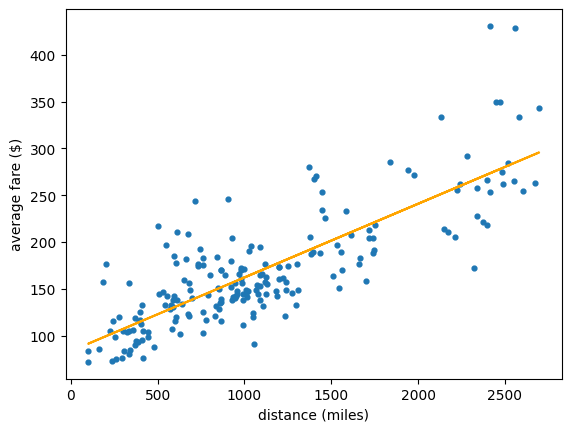

In [3]:
plt.scatter(routes['distance_mi'], routes['avg_fare'], s=12)
plt.plot(routes['distance_mi'], line.predict(X), color='orange')
plt.xlabel('distance (miles)')
plt.ylabel('average fare ($)')
plt.show()

In [4]:
# Predict the fare for a 1,000-mile market
print(line.predict(pd.DataFrame({'distance_mi': [1000]})).round(0))

[162.]


## 3. How much does distance explain? R²

$$R^2 = 1-\frac{\text{RSS}}{\text{TSS}},\qquad \text{TSS}=\sum_i (y_i-\bar y)^2$$

In [5]:
print('R2:', round(line.score(X, y), 3))

R2: 0.655


## 4. Where the line misses

In [6]:
routes['residual'] = routes['avg_fare'] - line.predict(X)
cols = ['airport_1', 'airport_2', 'distance_mi', 'avg_fare', 'lcc_share', 'top_airline', 'residual']

routes.sort_values('residual', ascending=False)[cols].head()     # dearer than distance says

,airport_1,airport_2,distance_mi,avg_fare,lcc_share,top_airline,residual
139,IAD,SFO,2413.0,430.98,0.009,UA,157.576587
11,EWR,SFO,2559.0,428.33,0.005,UA,143.432954
70,EWR,ORD,717.0,243.79,0.002,UA,103.901675
97,DTW,LGA,500.0,216.71,0.256,DL,93.904678
193,ATL,MSP,907.0,245.47,0.273,DL,90.624206


In [7]:
routes.sort_values('residual')[cols].head()                      # cheaper than distance says

,airport_1,airport_2,distance_mi,avg_fare,lcc_share,top_airline,residual
168,BWI,LAX,2324.0,172.50,0.608,WN,-93.897019
55,DFW,LAS,1053.0,90.77,0.421,AA,-75.569427
16,DFW,LAX,1232.0,121.25,0.212,AA,-59.180937
182,DEN,FLL,1702.0,158.49,0.704,NK,-58.940991
68,DEN,MCO,1544.0,150.42,0.727,WN,-54.572675


In [8]:
above = routes.sort_values('residual', ascending=False).head(20)
below = routes.sort_values('residual').head(20)
print('average lcc_share, 20 markets above the line:', round(above['lcc_share'].mean(), 2))
print('average lcc_share, 20 markets below the line:', round(below['lcc_share'].mean(), 2))

average lcc_share, 20 markets above the line: 0.12
average lcc_share, 20 markets below the line: 0.45


## 5. Would a curve help? Polynomial regression

Add a squared term so the line can bend:

$$\widehat{\text{fare}} = a + b_1 \times \text{distance} + b_2 \times \text{distance}^2$$

In [9]:
routes['distance_sq'] = routes['distance_mi'] ** 2
X_curve = routes[['distance_mi', 'distance_sq']]

curve = LinearRegression()
curve.fit(X_curve, y)
print('R2 with a curve:', round(curve.score(X_curve, y), 3))

R2 with a curve: 0.661


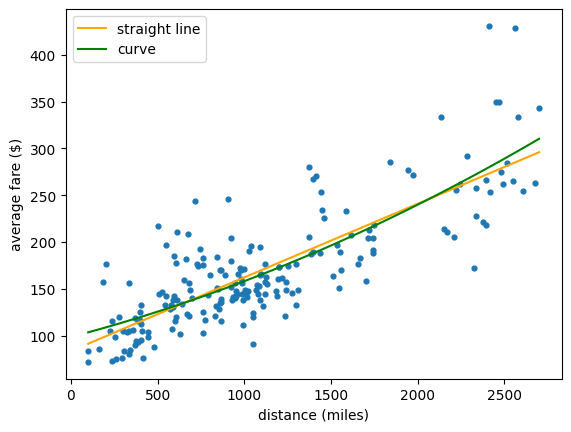

In [10]:
d = np.linspace(100, 2700, 100)
plt.scatter(routes['distance_mi'], routes['avg_fare'], s=12)
plt.plot(d, line.intercept_ + line.coef_[0] * d, color='orange', label='straight line')
plt.plot(d, curve.intercept_ + curve.coef_[0] * d + curve.coef_[1] * d ** 2, color='green', label='curve')
plt.xlabel('distance (miles)')
plt.ylabel('average fare ($)')
plt.legend()
plt.show()

## 6. A better input: low-cost competition

$$\widehat{\text{fare}} = a + b_1 \times \text{distance} + b_2 \times \text{lcc\_share}$$

In [11]:
X_lcc = routes[['distance_mi', 'lcc_share']]

multi = LinearRegression()
multi.fit(X_lcc, y)
print('coefficients (distance, lcc_share):', multi.coef_.round(4))
print('R2 with low-cost share:', round(multi.score(X_lcc, y), 3))

coefficients (distance, lcc_share): [  0.0702 -59.6926]
R2 with low-cost share: 0.72


### Your turn

Write the multiple regression yourself, with **distance** and **market concentration** (`hhi`) as the inputs. Print its R².

Fill in the blanks:

```python
X_hhi = routes[['__________', '___']]
model = LinearRegression()
model.fit(_____, _)
print(model.score(_____, _))
```

<details><summary>Show answer</summary>

```python
X_hhi = routes[['distance_mi', 'hhi']]
model = LinearRegression()
model.fit(X_hhi, y)
print(model.score(X_hhi, y))
```
</details>

In [12]:
# Write your code here

## 7. Summary

| Model | Inputs | R² |
|---|---|---|
| Straight line | distance | about 0.655 |
| Curve | distance, distance² | about 0.661 |
| Multiple regression | distance, low-cost share | about 0.720 |

The curve barely helps. A better input (competition) helps a lot.

---
## Challenge 1. Train and test
Split the markets 75% / 25% with `train_test_split(..., random_state=0)`. Fit the straight line on the
training set. What is the R² on the test set?

In [13]:
# Your answer

## Challenge 2. Add market concentration
Add `hhi` to the multiple regression. How much does R² rise? What sign does its coefficient take, and why?

In [14]:
# Your answer

## Challenge 3. A cubic curve
Add `distance_mi ** 3` to the curve model. Does R² rise? Is it worth it?

In [15]:
# Your answer

## Challenge 4. Explain
Two of the cheapest-for-distance markets start at DFW, where American is the top airline. What competition
could this data be missing? (Hint: Dallas has two airports.)